# **1. Setup**
---

In [ ]:
import os
import glob
import time
import tarfile
import math
import random
import warnings

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.transforms.functional import to_pil_image

import timm

warnings.simplefilter(action='ignore', category=FutureWarning)


def set_seed(seed, reproducibility=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility or Performance
    torch.backends.cudnn.deterministic = reproducibility
    torch.backends.cudnn.benchmark     = not reproducibility

In [ ]:
!pip install -q facenet-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.6/755.6 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16

In [ ]:
SEED = 42
set_seed(SEED, reproducibility=False)

TRAIN_DATA = '/kaggle/input/facereg-prepare-data/data/train'
TEST_DATA  = '/kaggle/input/facereg-prepare-data/data/test'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
nGPU   = torch.cuda.device_count()
print(f"Device: {DEVICE}")
print(f"nGPUs : {nGPU}")

Device: cuda
nGPUs : 2


# **2. Triplet Dataset**
---

In [ ]:
def gen_triplets(person_dirs, max_per_id=None): # Offline easy triplet mining
    triplets    = []
    person2imgs = {d: [os.path.join(d, f) for f in os.listdir(d) if f.endswith('.jpg')] for d in person_dirs} # {'0': [0_0001.jpg, 0_0002.jpg, ...]}
    others      = {d: [x for x in person_dirs if x != d]          for d in person_dirs}

    for d in tqdm(person_dirs, desc="Generating triplets...", leave=False):
        imgs = person2imgs[d]
        if len(imgs) < 2:
            continue

        anchor_pos = [(a, p) for i, a in enumerate(imgs) for p in imgs[i+1:]]
        if max_per_id:
            anchor_pos = random.sample(anchor_pos, min(max_per_id, len(anchor_pos)))

        for a, p in anchor_pos:
            neg_dir = random.choice(others[d])
            n = random.choice(person2imgs[neg_dir])
            triplets.append((a, p, n))
    return triplets

In [ ]:
class TripletDataset(Dataset):
    def __init__(self, triplets, transform):
        self.triplets  = triplets
        self.transform = transform

    def __len__(self): return len(self.triplets)

    def _read(self, path): return Image.open(path).convert('RGB')

    def __getitem__(self, idx):
        a_path, p_path, n_path = self.triplets[idx]
        return (self.transform(self._read(a_path)), # anchor image
                self.transform(self._read(p_path)), # positive image
                self.transform(self._read(n_path)), # negative image
                int(os.path.basename(os.path.dirname(a_path)))) # anchor image label

In [ ]:
from facenet_pytorch import MTCNN

IMG_SIZE   = 112
BATCH_SIZE = 128

face_detector = MTCNN(image_size=112, margin=10, device='cuda:0', post_process=False)

train_tf = transforms.Compose([
    # transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9,1.0)),
    # transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(IMG_SIZE),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    # transforms.Resize(int(IMG_SIZE * 1.1)),
    # transforms.CenterCrop(IMG_SIZE),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [ ]:
person_dirs          = sorted([os.path.join(TRAIN_DATA, d) for d in os.listdir(TRAIN_DATA)])
train_dirs, val_dirs = train_test_split(person_dirs, test_size=0.2, random_state=SEED)

train_triplets = gen_triplets(train_dirs, max_per_id=3000)
val_triplets   = gen_triplets(val_dirs  , max_per_id=3000)

# train_triplets = train_triplets[:400]
# val_triplets   = val_triplets[:150]

train_loader   = DataLoader(TripletDataset(train_triplets, train_tf), batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
val_loader     = DataLoader(TripletDataset(val_triplets, val_tf)    , batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train triplets: {len(train_triplets)}")
print(f"Val   triplets: {len(val_triplets)}")
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")

Generating triplets...:   0%|          | 0/84 [00:00<?, ?it/s]

Generating triplets...:   0%|          | 0/21 [00:00<?, ?it/s]

Train triplets: 252000
Val   triplets: 63000
Train batches : 1968
Val   batches : 493


# **3. Transfer Learning**
---

In [ ]:
class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50, easy_margin=False):
        super().__init__()
        
        self.in_features  = in_features
        self.out_features = out_features
        self.s = s
        self.m = m

        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.easy_margin = easy_margin
        self.cos_m       = math.cos(m)
        self.sin_m       = math.sin(m)
        self.th          = math.cos(math.pi - m)
        self.mm          = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight)) # (B, out_features)
        sine   = torch.sqrt(1.0 - torch.clamp(cosine**2, 0, 1))
        phi    = cosine * self.cos_m - sine * self.sin_m

        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, label.view(-1, 1), 1)

        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        return output * self.s

In [ ]:
class FaceNetArcFaceModel(nn.Module):
    def __init__(self, n_classes, backbone='efficientnet_b0', n_layers_unfreeze=10):
        super().__init__()
        
        self.backbone = timm.create_model(backbone, pretrained=True)
        self.backbone.classifier = nn.Identity()

        for p in self.backbone.parameters():                            p.requires_grad = False
        for p in list(self.backbone.parameters())[-n_layers_unfreeze:]: p.requires_grad = True

        feat_dim = self.backbone.num_features
        self.embedding_head = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.SiLU(), nn.BatchNorm1d(512), nn.Dropout(0.2),
            nn.Linear(512, 256)     , nn.SiLU(), nn.BatchNorm1d(256), nn.Dropout(0.1),
            nn.Linear(256, 128)     , nn.SiLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 128)
        )
        self.arc_margin = ArcMarginProduct(128, n_classes, s=30.0, m=0.50)

    def forward(self, x, label=None):
        feat = self.backbone(x)
        emb  = self.embedding_head(feat)
        emb  = F.normalize(emb, p=2, dim=1)

        if label is not None:
            arc_logits = self.arc_margin(emb, label)
            return emb, arc_logits
        else:
            return emb

In [ ]:
class EmbeddingModel(nn.Module):
    def __init__(self, backbone='efficientnet_b0', n_layers_unfreeze=10):
        super().__init__()
        
        self.backbone = timm.create_model(backbone, pretrained=True)
        self.backbone.classifier = nn.Identity()

        for p in self.backbone.parameters():                            p.requires_grad = False
        for p in list(self.backbone.parameters())[-n_layers_unfreeze:]: p.requires_grad = True

        feat_dim = self.backbone.num_features
        self.embedding_head = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.SiLU(), nn.BatchNorm1d(512), nn.Dropout(0.2),
            nn.Linear(512, 256)     , nn.SiLU(), nn.BatchNorm1d(256), nn.Dropout(0.1),
            nn.Linear(256, 128)     , nn.SiLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 128)
        )

    def forward(self, x):
        feat = self.backbone(x)
        emb  = self.embedding_head(feat)
        emb  = F.normalize(emb, p=2, dim=1)
        return emb

# **4. Training**
---

In [ ]:
def train_one_epoch(model, dataloader, triplet_criterion, ce_criterion, optimizer, device, alpha):
    model.train()
    total_loss, total_acc, total_samples = 0.0, 0.0, 0

    for a, p, n, label in tqdm(dataloader, desc='Training...'):
        a, p, n, label = a.to(device), p.to(device), n.to(device), label.to(device)

        optimizer.zero_grad()
        a_emb, a_logits = model(a, label)
        p_emb = model(p)
        n_emb = model(n)

        loss_triplet = triplet_criterion(a_emb, p_emb, n_emb)
        loss_ce      = ce_criterion(a_logits, label)
        loss         = alpha * loss_triplet + (1 - alpha) * loss_ce
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc  += (F.pairwise_distance(a_emb, p_emb) < F.pairwise_distance(a_emb, n_emb)).sum().item()
        total_samples += a.size(0)
    return total_loss / len(dataloader), total_acc / total_samples


def val_one_epoch(model, dataloader, triplet_criterion, ce_criterion, device, alpha):
    model.eval()
    total_loss, total_acc, total_samples = 0.0, 0.0, 0

    with torch.no_grad():
        for a, p, n, label in tqdm(dataloader, desc='Validation...'):
            a, p, n, label = a.to(device), p.to(device), n.to(device), label.to(device)

            a_emb, a_logits = model(a, label)
            p_emb = model(p)
            n_emb = model(n)
    
            loss_triplet = triplet_criterion(a_emb, p_emb, n_emb)
            loss_ce      = ce_criterion(a_logits, label)
            loss         = alpha * loss_triplet + (1 - alpha) * loss_ce

            total_loss += loss.item()
            total_acc  += (F.pairwise_distance(a_emb, p_emb) < F.pairwise_distance(a_emb, n_emb)).sum().item()
            total_samples += a.size(0)
    return total_loss / len(dataloader), total_acc / total_samples

In [ ]:
def trainer(model, train_loader, val_loader, triplet_criterion, ce_criterion, optimizer, 
            scheduler, early_stop_patience, min_delta,
            device, num_epochs, alpha, save_path):
    
    history          = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc     = 0.0
    patience_counter = 0
    
    start_time = time.time()
    for epoch in range(1, num_epochs+1):
        epoch_start = time.time()
        print(f"\n[Epoch {epoch}/{num_epochs}]")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, triplet_criterion, ce_criterion, optimizer, device, alpha=alpha)
        val_loss, val_acc     = val_one_epoch(model, val_loader, triplet_criterion, ce_criterion, device, alpha=alpha)
        
        scheduler.step(val_loss)
        
        print(f"-  Current LR: {scheduler.get_last_lr()[0]:.2e}")
        print(f"-  Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
        print(f"-  Val   Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
        print(f"-  Epoch Time: {(time.time() - epoch_start):.2f}s")
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(scheduler.get_last_lr()[0])

        if val_acc > best_val_acc + min_delta:
            best_val_acc     = val_acc
            patience_counter = 0
            
            torch.save({
                'epoch'          : epoch,
                'model_state'    : model.state_dict(),
                'model_backbone' : model.backbone.state_dict(),
                'model_embedding': model.embedding_head.state_dict(),
                'opt_state'      : optimizer.state_dict(),
                'sch_state'      : scheduler.state_dict(),
                'val_acc'        : val_acc
            }, save_path)
            print(f"-> Best model saved with val acc {best_val_acc:.4f}")
        else:
            patience_counter += 1
            print(f"-> No significant improvement (delta <= {min_delta:.1e}), patience: {patience_counter}/{early_stop_patience}")
            if patience_counter >= early_stop_patience:
                print("-> Early stopping triggered")
                break

                
    end_time = time.time()
    print(f"\n=> Training complete in {(end_time - start_time):.2f}s. Best validation acc: {best_val_acc:.4f}")
    return history

In [ ]:
model = FaceNetArcFaceModel(n_classes=len(os.listdir(TRAIN_DATA)), backbone='efficientnet_b0', n_layers_unfreeze=10)
model.to(DEVICE)

triplet_criterion = nn.TripletMarginLoss(margin=0.5, p=2)
ce_criterion      = nn.CrossEntropyLoss()
optimizer         = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler         = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)

os.makedirs('results/models', exist_ok=True)
MODEL_PATH = 'results/models/best_model.pt'

history = trainer(model, train_loader, val_loader, 
                  triplet_criterion, ce_criterion, optimizer, 
                  scheduler, early_stop_patience=3, min_delta=1e-4,
                  device=DEVICE, num_epochs=30, 
                  alpha=0.9, save_path=MODEL_PATH)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


[Epoch 1/30]


Training...:   0%|          | 0/1968 [00:00<?, ?it/s]

Validation...:   0%|          | 0/493 [00:00<?, ?it/s]

-  Current LR: 3.00e-04
-  Train Loss: 1.7479, Accuracy: 0.8188
-  Val   Loss: 3.1371, Accuracy: 0.7788
-  Epoch Time: 959.82s
-> Best model saved with val acc 0.7788

[Epoch 2/30]


...

Validation...:   0%|          | 0/493 [00:00<?, ?it/s]

-  Current LR: 3.00e-04
-  Train Loss: 0.4986, Accuracy: 0.9674
-  Val   Loss: 4.0685, Accuracy: 0.7657
-  Epoch Time: 960.87s
-> No significant improvement (delta <= 1.0e-04), patience: 2/3

[Epoch 5/30]


Training...:   0%|          | 0/1968 [00:00<?, ?it/s]

Validation...:   0%|          | 0/493 [00:00<?, ?it/s]

-  Current LR: 3.00e-05
-  Train Loss: 0.3945, Accuracy: 0.9741
-  Val   Loss: 4.1040, Accuracy: 0.7688
-  Epoch Time: 955.12s
-> No significant improvement (delta <= 1.0e-04), patience: 3/3
-> Early stopping triggered

=> Training complete in 4755.50s. Best validation acc: 0.7793


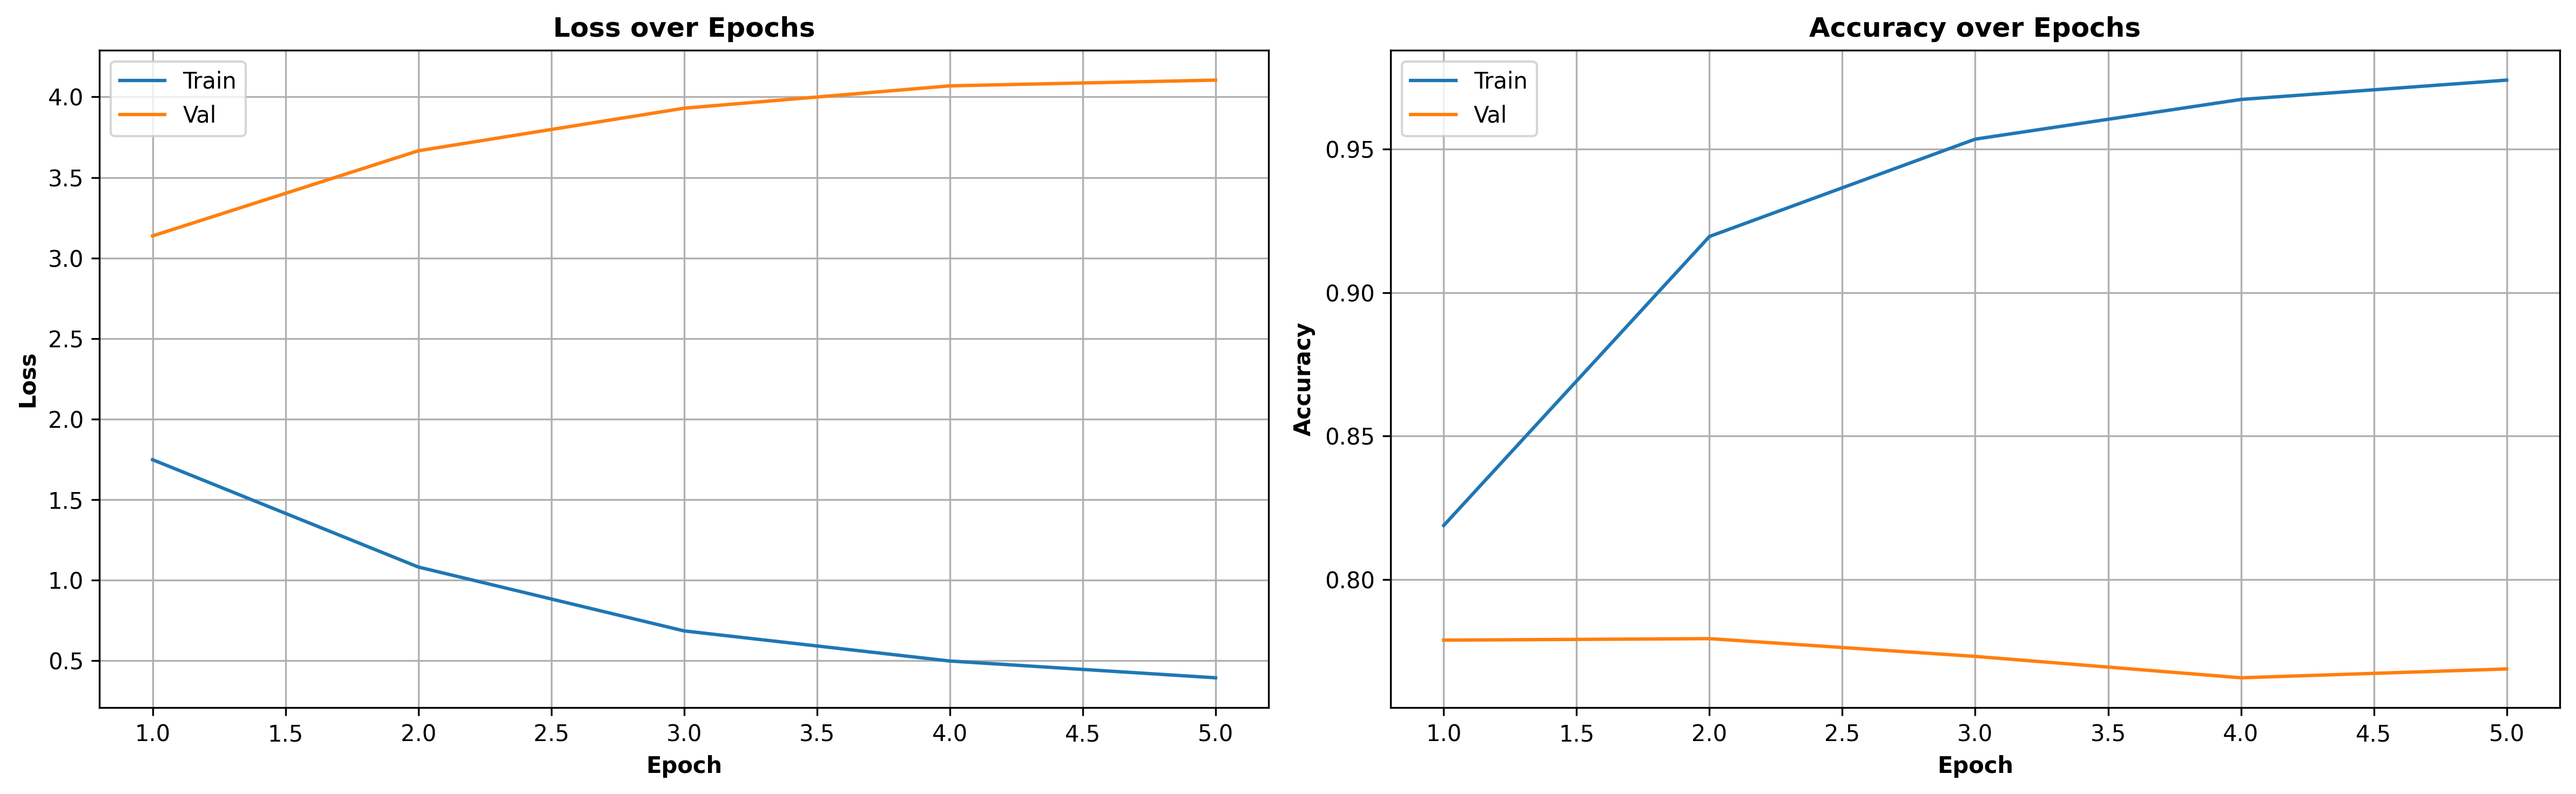

In [ ]:
epochs_tick = range(1, len(history['train_loss']) + 1)
fig, axs = plt.subplots(1, 2, figsize=(16, 5), dpi=300)

for ax, metric, ylabel in zip(axs, ['loss', 'acc'], ['Loss', 'Accuracy']):
    ax.plot(epochs_tick, history[f'train_{metric}'], label='Train')
    ax.plot(epochs_tick, history[f'val_{metric}'],   label='Val')
    ax.set_title(f'{ylabel} over Epochs', fontweight='bold')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.legend()
    ax.grid(True)
    
plt.tight_layout()
plt.show()

# **5. Testing**
---

In [ ]:
def load_lfw_pairs(pairs_txt_path, lfw_dir):
    same_pairs = []
    diff_pairs = []

    with open(pairs_txt_path, 'r') as f:
        lines = f.readlines()[1:]  # bỏ dòng đầu tiên (header)

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 3:
            name, idx1, idx2 = parts
            path1 = os.path.join(lfw_dir, name, f"{name}_{int(idx1):04d}.jpg")
            path2 = os.path.join(lfw_dir, name, f"{name}_{int(idx2):04d}.jpg")
            same_pairs.append((path1, path2))
        elif len(parts) == 4:
            name1, idx1, name2, idx2 = parts
            path1 = os.path.join(lfw_dir, name1, f"{name1}_{int(idx1):04d}.jpg")
            path2 = os.path.join(lfw_dir, name2, f"{name2}_{int(idx2):04d}.jpg")
            diff_pairs.append((path1, path2))
    return same_pairs, diff_pairs

In [ ]:
def compute_embeddings(model, pairs, face_detector, device):
    model.eval()
    embeddings = []
    
    for img1_path, img2_path in tqdm(pairs):
        face1 = face_detector(Image.open(img1_path).convert("RGB"))
        face2 = face_detector(Image.open(img2_path).convert("RGB"))
        
        if face1 is None or face2 is None:
            embeddings.append(0.0) # sim=0.0
            continue

        face1 = face1.unsqueeze(0).to(device) # [1, 3, 128, 128]
        face2 = face2.unsqueeze(0).to(device) 

        with torch.no_grad():
            emb1 = model(face1)  # Output: [1, 128]
            emb2 = model(face2)

        sim = F.cosine_similarity(emb1, emb2).item()
        embeddings.append(sim)

    return embeddings

In [ ]:
def evaluate_verification(sim_same, sim_diff):
    labels = [1] * len(sim_same) + [0] * len(sim_diff)
    scores = sim_same + sim_diff

    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    # Accuracy at best threshold
    accs = [(np.mean((np.array(scores) > t) == np.array(labels)), t) for t in thresholds]
    best_acc, best_thresh = max(accs)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Face Verification (LFW)")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f'Best Accuracy: {best_acc:.4f} at threshold = {best_thresh:.4f}')
    print(f'AUC: {roc_auc:.4f}')

In [ ]:
def load_model(model, model_path, device):
    state = torch.load(model_path, map_location=device)

    model.backbone.load_state_dict(state['model_backbone'])
    model.embedding_head.load_state_dict(state['model_embedding'])
    model.to(device)
    return model.eval()

emb_model = load_model(EmbeddingModel(), MODEL_PATH, DEVICE)

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

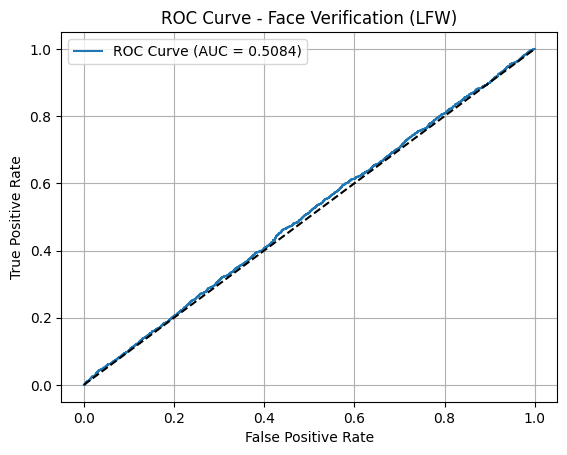

Best Accuracy: 0.5103 at threshold = 0.3560
AUC: 0.5084


In [ ]:
pairs_txt = f"{TEST_DATA}/pairs.txt"
lfw_dir   = TEST_DATA

same_pairs, diff_pairs = load_lfw_pairs(pairs_txt, lfw_dir)

sim_same = compute_embeddings(emb_model, same_pairs, face_detector=face_detector, device=DEVICE)
sim_diff = compute_embeddings(emb_model, diff_pairs, face_detector=face_detector, device=DEVICE)

evaluate_verification(sim_same, sim_diff)